In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Get Nowdays NVDA info
def get_nvidia_quote() -> dict:
    ticker = yf.Ticker("NVDA") #ticker.info로 해당 주식의 정보 확인 가능(주소, 기업소개, ir공시 사이트, 직원수, 임원 명단 등)
    history = ticker.history(period="5d", interval="1d")

    if history.empty:
        raise RuntimeError("No price data returned from Yahoo Finance.")

    latest = history.tail(1).iloc[0]
    return {
        "symbol": "NVDA",
        "date": history.tail(1).index[0].strftime("%Y-%m-%d"),
        "open": float(latest["Open"]),
        "high": float(latest["High"]),
        "low": float(latest["Low"]),
        "close": float(latest["Close"]),
        "volume": int(latest["Volume"]),
    }


In [3]:
quote = get_nvidia_quote()

print(f"Symbol : {quote['symbol']}")
print(f"Date   : {quote['date']}")
print(f"Open   : {quote['open']:.2f}")
print(f"High   : {quote['high']:.2f}")
print(f"Low    : {quote['low']:.2f}")
print(f"Close  : {quote['close']:.2f}")
print(f"Volume : {quote['volume']:,}")

Symbol : NVDA
Date   : 2026-07-02
Open   : 197.14
High   : 200.06
Low    : 192.35
Close  : 194.83
Volume : 142,068,700


In [4]:
month = float(input('Enter the month what you want to get the Ticker data (ex: 5): '))
end_date = datetime.now()

start_date = end_date - timedelta(days = 30*month)
end_date = end_date.strftime("%Y-%m-%d")
start_data = start_date.strftime("%Y-%m-%d")

In [9]:
df = yf.download(yf.Ticker(input('Enter the Ticker you want to get the data (ex: NVDA): ')).info['symbol'], start=start_date, end=end_date, interval='1d').sort_index(ascending=True)
# 2. 이동평균선(SMA) 및 볼린저 밴드 계산
period = 30  # 기준 기간 (보통 20일을 가장 많이 씁니다)

# 20일 이동평균선 (볼린저 밴드의 중심선이 됩니다)
df['MA30'] = df['Close'].rolling(window=period).mean()

# 20일 표준편차 계산
df['STD30'] = df['Close'].rolling(window=period).std()

# 상단 밴드 = 중심선 + (표준편차 * 2)
df['Upper_Band'] = df['MA30'] + (df['STD30'] * 2)

# 하단 밴드 = 중심선 - (표준편차 * 2)
df['Lower_Band'] = df['MA30'] - (df['STD30'] * 2)

# 인덱스를 일반 칼럼으로 변환
df = df.reset_index()
df = df.sort_values(by='Date', ascending=False)
# MultiIndex 컬럼이 있다면 평탄화
df.columns = [
    "_".join(col).strip() if isinstance(col, tuple) else col
    for col in df.columns
]

df.head()

[*********************100%***********************]  1 of 1 completed


,Date_,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,MA30_,STD30_,Upper_Band_,Lower_Band_
100,2026-07-02,194.830002,200.059998,192.350006,197.139999,142068700,208.008675,8.931937,225.872548,190.144801
99,2026-07-01,197.580002,199.850006,193.449997,196.199997,146147600,208.859447,8.848535,226.556516,191.162378
98,2026-06-30,200.089996,200.630005,195.110001,197.240005,166476700,209.675487,8.901149,227.477785,191.873189
97,2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,210.507744,9.138088,228.783920,192.231569
96,2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,211.857597,9.735190,231.327976,192.387218


In [7]:
df.to_excel('nvidia_price.xlsx', index=False)  # Save to Excel

In [16]:
df.head()

Price,Close,High,Low,Open,Volume,MA20,STD20,Upper_Band,Lower_Band
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,
Date,,,,,,,,,
2026-02-06,185.184128,186.772187,174.387300,176.474750,231346200,NaN,NaN,NaN,NaN
2026-02-09,189.808487,193.424087,183.725909,184.035529,196387400,NaN,NaN,NaN,NaN
2026-02-10,188.310318,192.245521,187.890831,191.146870,136764800,NaN,NaN,NaN,NaN
2026-02-11,189.818481,193.024562,188.540042,192.215552,144192700,NaN,NaN,NaN,NaN
2026-02-12,186.712280,193.374153,186.282796,192.794858,189932500,NaN,NaN,NaN,NaN


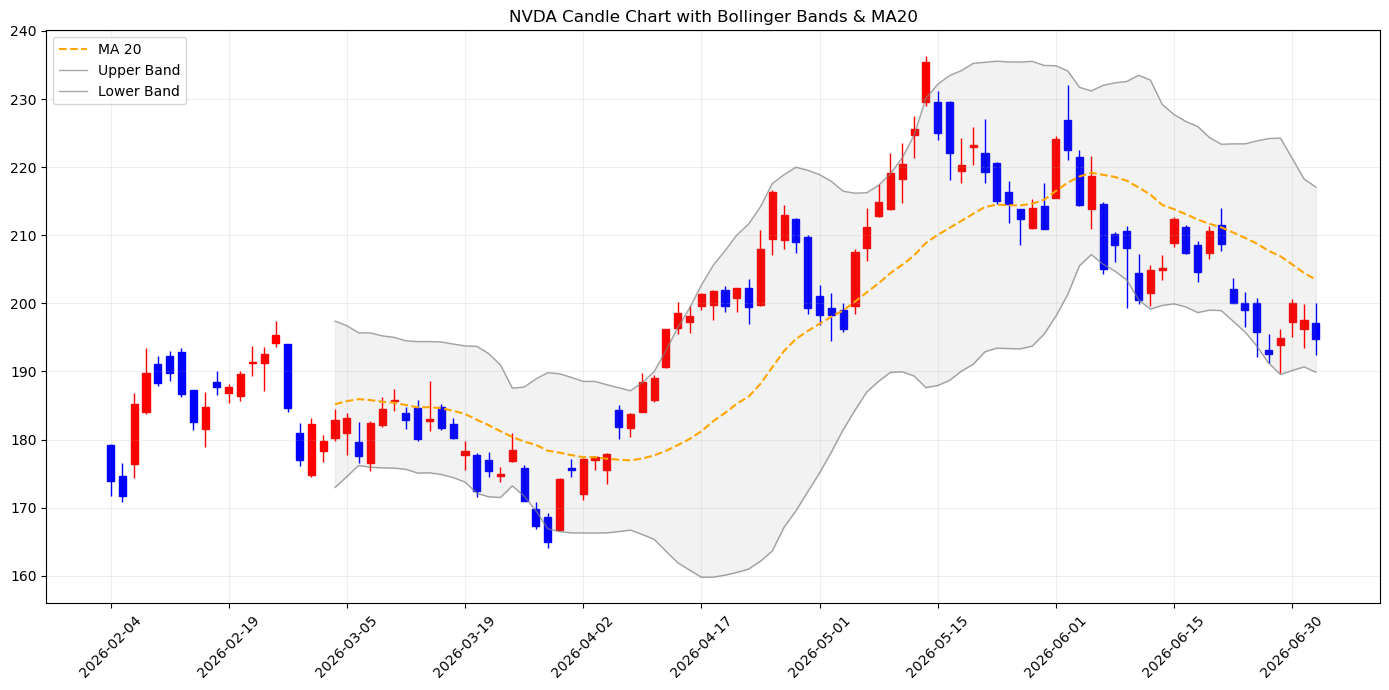

In [6]:
# 2. 시각화를 위해 인덱스(날짜)를 숫자로 다루기 편하게 리셋
df_reset = df.reset_index()
# ----------------------------------------------------
# 1. 그래프 도화지 그리기
fig, ax = plt.subplots(figsize=(14, 7))

# 2. 기존 캔들차트 그리기 (반복문 코드)
for i in range(len(df_reset)):
    row = df_reset.iloc[i]
    
    open_val = row['Open'].item()
    high_val = row['High'].item()
    low_val = row['Low'].item()
    close_val = row['Close'].item()
    
    if close_val >= open_val:
        color = 'red'
        bottom = open_val
        height = close_val - open_val
    else:
        color = 'blue'
        bottom = close_val
        height = open_val - close_val
        
    ax.vlines(i, low_val, high_val, color=color, linewidth=1)
    ax.add_patch(plt.Rectangle((i - 0.3, bottom), 0.6, height, color=color))

# ----------------------------------------------------
# 3. 🌟 이평선 및 볼린저 밴드 선 추가하기
x_range = range(len(df_reset))

# 20일 이동평균선 (중앙 점선 형태)
ax.plot(x_range, df_reset['MA20'], label='MA 20', color='orange', linewidth=1.5, linestyle='--')

# 볼린저 밴드 상한선 및 하한선
ax.plot(x_range, df_reset['Upper_Band'], label='Upper Band', color='gray', linewidth=1, alpha=0.7)
ax.plot(x_range, df_reset['Lower_Band'], label='Lower Band', color='gray', linewidth=1, alpha=0.7)

# 볼린저 밴드 내부 채우기 (alpha로 반투명도 조절)
ax.fill_between(x_range, df_reset['Lower_Band'], df_reset['Upper_Band'], color='gray', alpha=0.1)

# ----------------------------------------------------
# 4. 마무리 스타일링 및 축 설정
date_series = df_reset['Date']
if isinstance(date_series, pd.DataFrame):
    date_series = date_series.iloc[:, 0]
date_series = pd.to_datetime(date_series)
labels = date_series.dt.strftime('%Y-%m-%d')

step = max(1, len(df_reset) // 10)
tick_positions = range(0, len(df_reset), step)
ax.set_xticks(tick_positions)
ax.set_xticklabels(labels.iloc[list(tick_positions)], rotation=45)

plt.title("NVDA Candle Chart with Bollinger Bands & MA20")
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left') # 범례 추가
plt.tight_layout()
plt.show()